##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [1]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

2.11.0+cu128
True
NVIDIA GeForce RTX 5070 Laptop GPU


In [3]:
%pip install datasets transformers scikit-learn matplotlib pillow requests

^C
Note: you may need to restart the kernel to use updated packages.


Using device: cuda


Loading weights: 100%|██████████| 223/223 [00:00<00:00, 4938.15it/s]


Embedding shape: (20, 384)
Ground-truth labels: [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
Raw KMeans clusters: [0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 1 1 1 1 1]
Mapped predicted labels: [0 1 1 0 0 0 0 0 0 0 0 1 0 1 0 1 1 1 1 1]
Clustering Accuracy: 75.00%

Classification Report:
              precision    recall  f1-score   support

         Cat       0.73      0.80      0.76        10
         Dog       0.78      0.70      0.74        10

    accuracy                           0.75        20
   macro avg       0.75      0.75      0.75        20
weighted avg       0.75      0.75      0.75        20



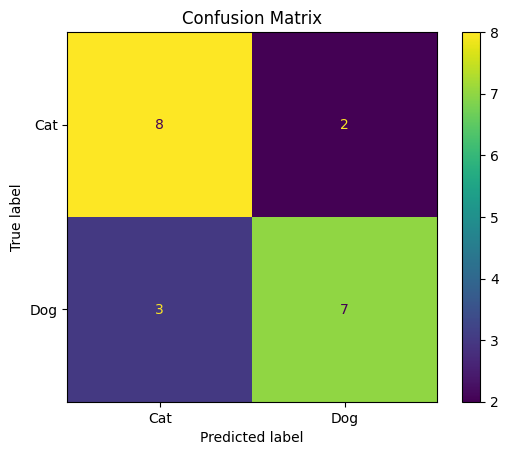

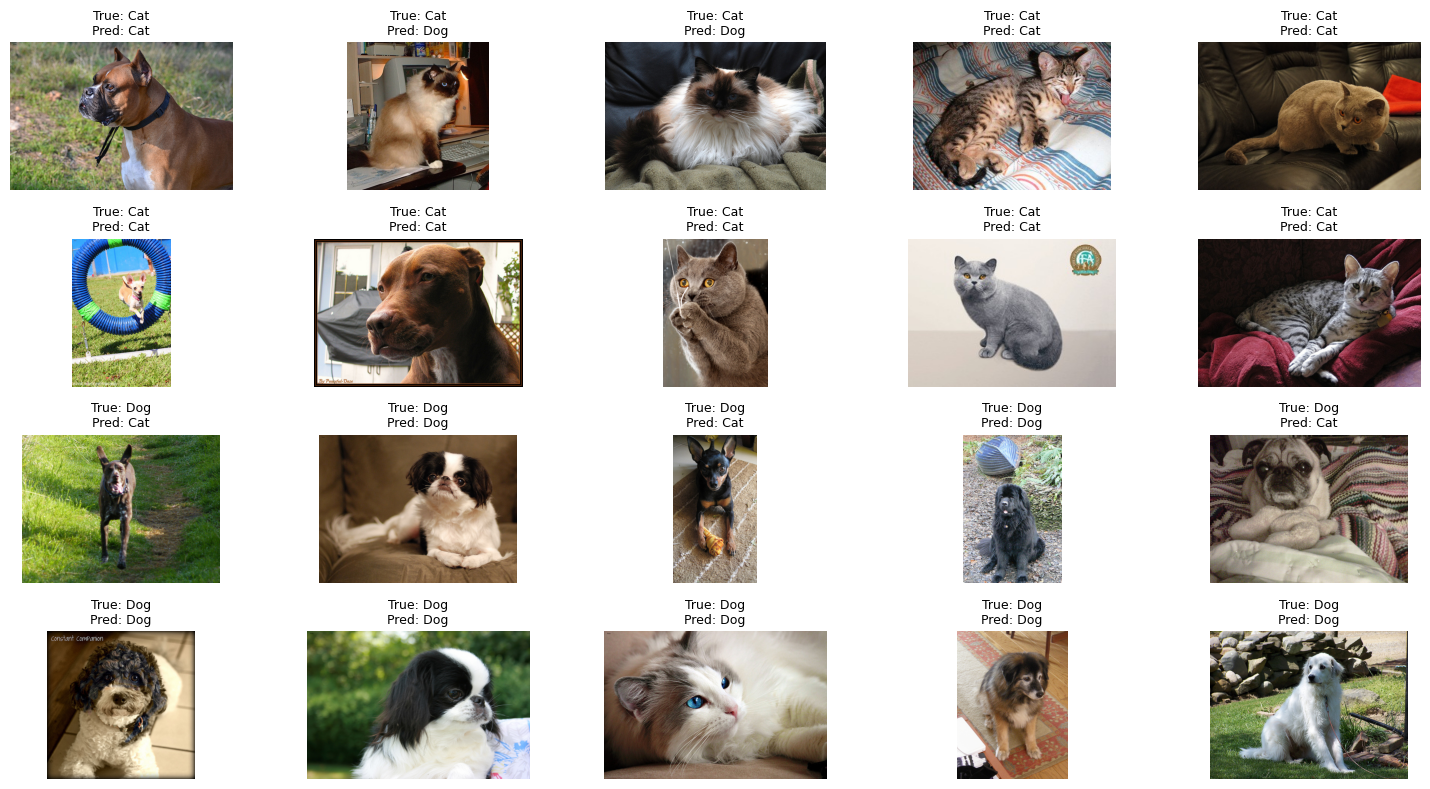

In [5]:
# Provide your solution here

import torch
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModel
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import normalize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

dataset = load_dataset("timm/oxford-iiit-pet", split="test")

model_id = "facebook/dinov2-small"
processor = AutoImageProcessor.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id).to(device)
model.eval()

# Separate cats and dogs
cat_samples = []
dog_samples = []

for sample in dataset:
    label = sample["label"]

    # Oxford-IIIT Pet: labels 0-11 are cats, labels 12-36 are dogs
    if label < 12:
        cat_samples.append(sample)
    else:
        dog_samples.append(sample)

# Choose balanced random samples
np.random.seed(7)

selected_cats = np.random.choice(cat_samples, 10, replace=False)
selected_dogs = np.random.choice(dog_samples, 10, replace=False)

selected_samples = list(selected_cats) + list(selected_dogs)

images = []
labels = []

for sample in selected_samples:
    image = sample["image"].convert("RGB")
    label = sample["label"]

    images.append(image)
    labels.append(0 if label < 12 else 1)  # 0 = Cat, 1 = Dog

labels = np.array(labels)

# Extract CLS embeddings
embeddings = []

for image in images:
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    cls_token = outputs.last_hidden_state[:, 0, :]
    embeddings.append(cls_token.squeeze().cpu().numpy())

embeddings = np.array(embeddings)

print("Embedding shape:", embeddings.shape)

# Normalize embeddings before clustering
embeddings_norm = normalize(embeddings, norm="l2")

# KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=50)
clusters = kmeans.fit_predict(embeddings_norm)

# Fix possible cluster-label swap
acc1 = accuracy_score(labels, clusters)
acc2 = accuracy_score(labels, 1 - clusters)

if acc2 > acc1:
    predicted_labels = 1 - clusters
else:
    predicted_labels = clusters

accuracy = accuracy_score(labels, predicted_labels)

print("Ground-truth labels:", labels)
print("Raw KMeans clusters:", clusters)
print("Mapped predicted labels:", predicted_labels)
print(f"Clustering Accuracy: {accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(labels, predicted_labels, target_names=["Cat", "Dog"]))

# Confusion Matrix
cm = confusion_matrix(labels, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Cat", "Dog"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# Display example photos
plt.figure(figsize=(15, 8))

for i in range(len(images)):
    plt.subplot(4, 5, i + 1)
    plt.imshow(images[i])
    plt.axis("off")

    true_label = "Cat" if labels[i] == 0 else "Dog"
    pred_label = "Cat" if predicted_labels[i] == 0 else "Dog"

    plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=9)

plt.tight_layout()
plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

Using device: cuda


c:\Aseel_IAU\ARTI560-computer-vision-labs\cv_lab\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\a2092\.cache\huggingface\hub\models--facebook--dinov2-small-imagenet1k-1-layer. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 225/225 [00:00<00:00, 4359.30it/s]


Predicted label: golden retriever


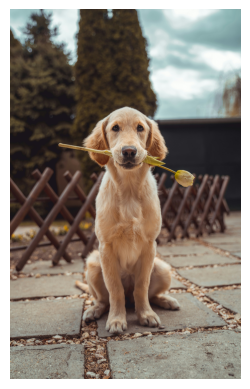

In [3]:
# Provide your solution here

import torch
import requests
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model_id = "facebook/dinov2-small-imagenet1k-1-layer"

processor = AutoImageProcessor.from_pretrained(model_id)
model = AutoModelForImageClassification.from_pretrained(model_id)
model.to(device)
model.eval()

url = "https://images.unsplash.com/photo-1552053831-71594a27632d"
image = Image.open(requests.get(url, stream=True).raw).convert("RGB")

inputs = processor(images=image, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = model(**inputs)

predicted_class = outputs.logits.argmax(-1).item()
predicted_label = model.config.id2label[predicted_class]

print("Predicted label:", predicted_label)

plt.imshow(image)
plt.axis("off")
plt.show()